## Medical disease prediction


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## Load Dataset


In [8]:
df = pd.read_csv(r"Data\medical_disease_prediction_10000.csv")
df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy


In [9]:
df.shape

(10000, 12)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   Gender            10000 non-null  str    
 2   BMI               10000 non-null  float64
 3   BloodPressure     10000 non-null  int64  
 4   GlucoseLevel      10000 non-null  int64  
 5   Cholesterol       10000 non-null  int64  
 6   HeartRate         10000 non-null  int64  
 7   Smoking           10000 non-null  str    
 8   Alcohol           10000 non-null  str    
 9   PhysicalActivity  10000 non-null  str    
 10  FamilyHistory     10000 non-null  str    
 11  Disease           10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace = True)
df.dropna(inplace = True)
df.shape

(10000, 12)

## Target Column Analysis

In [13]:
df['Disease'].value_counts()

Disease
Healthy          6329
Hypertension     1771
Pre-Diabetes     1453
Heart Disease     232
Diabetes          215
Name: count, dtype: int64

In [14]:
df['Disease'].value_counts(normalize = True) * 100

Disease
Healthy          63.29
Hypertension     17.71
Pre-Diabetes     14.53
Heart Disease     2.32
Diabetes          2.15
Name: proportion, dtype: float64

## EDA Graphs

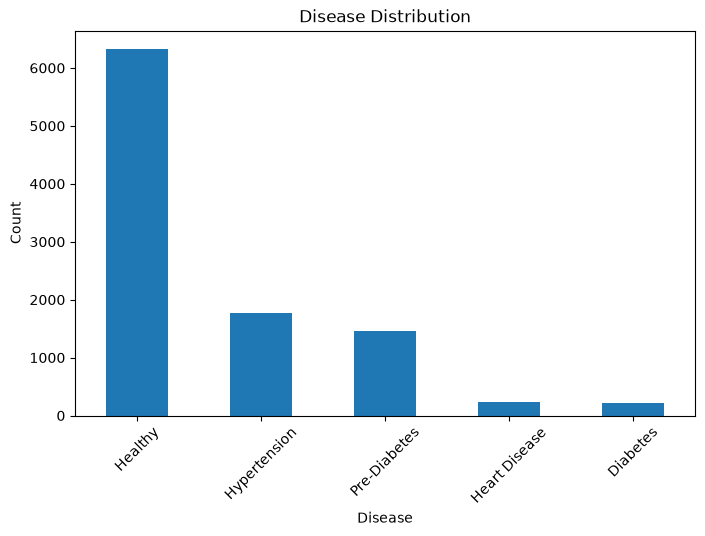

In [15]:
plt.figure(figsize=(8,5))
df['Disease'].value_counts().plot(kind = 'bar')
plt.title('Disease Distribution')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

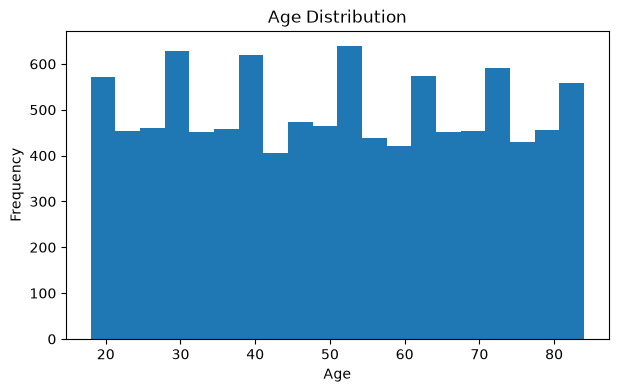

In [16]:
plt.figure(figsize = (7,4))
df['Age'].plot(kind='hist',bins = 20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

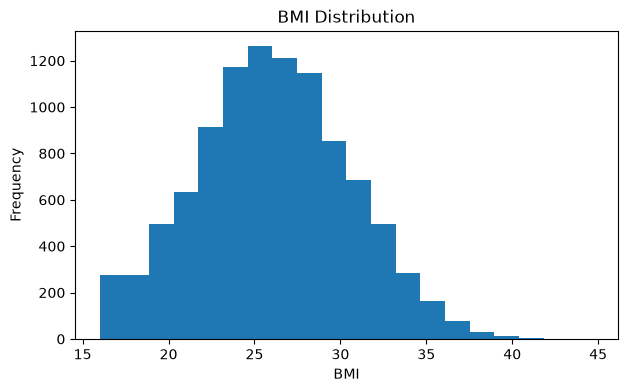

In [17]:
plt.figure(figsize = (7,4))
df['BMI'].plot(kind = 'hist',bins = 20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

## Encoding Categorial Columns

In [18]:
df['Gender'].unique(),df['Smoking'].unique(),df['Alcohol'].unique(),df['PhysicalActivity'].unique(),df['FamilyHistory'].unique(),df['Disease'].unique()

(<StringArray>
 ['Male', 'Female']
 Length: 2, dtype: str,
 <StringArray>
 ['No', 'Yes']
 Length: 2, dtype: str,
 <StringArray>
 ['No', 'Yes']
 Length: 2, dtype: str,
 <StringArray>
 ['Medium', 'High', 'Low']
 Length: 3, dtype: str,
 <StringArray>
 ['No', 'Yes']
 Length: 2, dtype: str,
 <StringArray>
 ['Healthy', 'Pre-Diabetes', 'Hypertension', 'Heart Disease', 'Diabetes']
 Length: 5, dtype: str)

In [19]:
Gender_dict = {'Male':1,'Female' : 2}
Smoking_dict = {'No':1,'Yes' : 2}
Alcohol_dict = {'No':1,'Yes':2}
PhysicalActivity_dict = {'Low':1,'Medium':2,'High':3}
FamilyHistory_dict = {'No':1,'Yes':2}
Disease_dict = {'Healthy' : 0,'Hypertension':1,'Pre-Diabetes':2,'Heart Disease':3,'Diabetes':4}

df['Gender'] = df['Gender'].map(Gender_dict)
df['Smoking'] = df['Smoking'].map(Smoking_dict)
df['Alcohol'] = df['Alcohol'].map(Alcohol_dict)
df['PhysicalActivity'] = df['PhysicalActivity'].map(PhysicalActivity_dict)
df['FamilyHistory'] = df['FamilyHistory'].map(FamilyHistory_dict)
df['Disease'] = df['Disease'].map(Disease_dict)


df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,1,1,2,1,0
1,69,1,31.1,118,256,147,92,1,1,3,2,2
2,61,2,31.3,114,206,193,74,2,1,2,1,0
3,47,2,23.9,105,162,253,68,1,1,1,1,0
4,47,1,28.3,148,121,280,84,1,2,3,1,0


In [20]:
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

## Correlation Heatmap

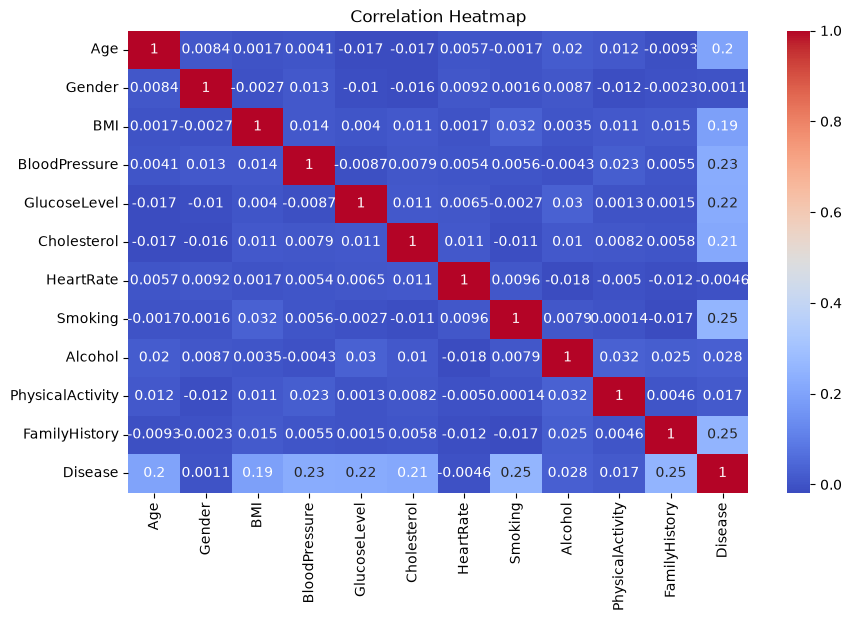

In [21]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(),annot = True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## Feature and Target Split

In [22]:
x = df.drop('Disease',axis = 1)
y = df['Disease']

x.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory
0,23,1,17.5,102,177,161,88,1,1,2,1
1,69,1,31.1,118,256,147,92,1,1,3,2
2,61,2,31.3,114,206,193,74,2,1,2,1
3,47,2,23.9,105,162,253,68,1,1,1,1
4,47,1,28.3,148,121,280,84,1,2,3,1


In [23]:
y.head()

0    0
1    2
2    0
3    0
4    0
Name: Disease, dtype: int64

## Train Test Split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size = 0.2,random_state = 42,stratify = y

)

x_train.shape,x_test.shape

((8000, 11), (2000, 11))

## Feature Scaling

In [25]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)


## Baseline SVC Model

In [26]:
svc = SVC()
svc.fit(x_train_sc,y_train)

svc_train = svc.score(x_train_sc,y_train)
svc_test = svc.score(x_test_sc,y_test)

print('SVC Training Score:',svc_train)
print('SVC Testing score:',svc_test)

SVC Training Score: 0.69325
SVC Testing score: 0.6625


In [27]:
svc_pred = svc.predict(x_test_sc)
print(classification_report(y_test,svc_pred,zero_division = 0))


              precision    recall  f1-score   support

           0       0.72      0.95      0.82      1266
           1       0.38      0.32      0.35       354
           2       0.25      0.01      0.03       291
           3       0.00      0.00      0.00        46
           4       0.18      0.05      0.07        43

    accuracy                           0.66      2000
   macro avg       0.31      0.27      0.25      2000
weighted avg       0.56      0.66      0.59      2000



In [28]:
model_result =[]

for c_value in [0.1,0.5,1,2,5]:
    temp_model = SVC(C=c_value,kernel='rbf',gamma = 'scale')
    temp_model.fit(x_train_sc,y_train)
    temp_score = temp_model.score(x_test_sc,y_test)
    model_result.append([c_value,temp_score])


result_df = pd.DataFrame(model_result,columns=['C Value','Testing score'])
result_df

,C Value,Testing score
0,0.1,0.6565
1,0.5,0.6630
2,1.0,0.6625
3,2.0,0.6585
4,5.0,0.6580


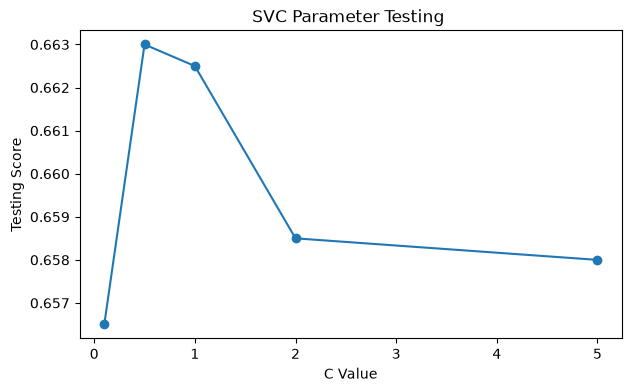

In [29]:
plt.figure(figsize = (7,4))
plt.plot(result_df['C Value'], result_df['Testing score'], marker ='o')
plt.title('SVC Parameter Testing ')
plt.xlabel('C Value')
plt.ylabel('Testing Score')
plt.show()

In [30]:
best_c = result_df.sort_values(by = 'Testing score',ascending = False).iloc[0]['C Value']
best_c

np.float64(0.5)

In [31]:
final_model = SVC(C=best_c,kernel = 'rbf',gamma = 'scale',probability = True)
final_model.fit(x_train_sc,y_train)

print('Final SVC Training Score:',final_model.score(x_train_sc,y_train))
print('Final SVC Testing Score:',final_model.score(x_test_sc,y_test))

c:\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Final SVC Training Score: 0.673
Final SVC Testing Score: 0.663


In [32]:
final_pred = final_model.predict(x_test_sc)
print(classification_report(y_test,final_pred,zero_division = 0))

              precision    recall  f1-score   support

           0       0.72      0.96      0.82      1266
           1       0.36      0.31      0.33       354
           2       0.00      0.00      0.00       291
           3       0.00      0.00      0.00        46
           4       0.00      0.00      0.00        43

    accuracy                           0.66      2000
   macro avg       0.22      0.25      0.23      2000
weighted avg       0.52      0.66      0.58      2000



## Confusion Matrix

In [33]:
cm = confusion_matrix(y_test,final_pred)
cm

array([[1217,   49,    0,    0,    0],
       [ 244,  109,    0,    0,    1],
       [ 230,   61,    0,    0,    0],
       [   5,   41,    0,    0,    0],
       [   4,   39,    0,    0,    0]])

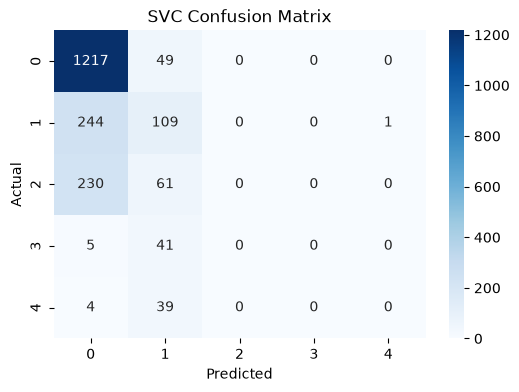

In [34]:
plt.figure(figsize = (6,4))
sns.heatmap(cm,annot = True,fmt = 'd',cmap='Blues')
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Save Final Model and Scaler

In [35]:
joblib.dump(final_model, 'medical_svc_model.lb')
joblib.dump(sc,'medical_scaler.lb')

['medical_scaler.lb']

## Single Prediction Example

In [36]:
x.columns

Index(['Age', 'Gender', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Cholesterol',
       'HeartRate', 'Smoking', 'Alcohol', 'PhysicalActivity', 'FamilyHistory'],
      dtype='str')

In [38]:
sample_data = pd.DataFrame([[45,28.5,130,110,210,82,1,2,1,2,2]],columns = x.columns)

sample_data_sc = sc.transform(sample_data)
prediction = final_model.predict(sample_data_sc)
prediction

array([0])

In [45]:
reverse_disease_dict = {
    0:'Healthy',
    1:'Hypertension',
    2:'Pre-Diabetes',
    3:'Heart Disease',
    4:'Diabetes'
}

print('Predicted Disease is:',reverse_disease_dict[prediction[0]])

Predicted Disease is: Healthy
